# Sector-Based Stationarity Analysis — iRacing Telemetry
## ADF & KPSS Tests per Track Sector × Driver × Stint

**Pipeline (fully automatic — no manual driver/stint selection):**
1. Import shared `config` and `telemetry` modules
2. Load **every** `(track, driver, stint)` combination registered in `DATASETS` — multi-file stints are concatenated automatically
3. Assign each telemetry sample to a track sector using `LapDistPct`
4. Compute per-lap sector statistics: Mean / Std of TotalG, Speed, Throttle, Brake, Steering
5. Run ADF + KPSS on each `(driver, track, stint, sector, variable)` discrete time series
6. Visualise results and build the **cross-driver stationarity summary** (§10–12)
7. Export the final summary tables (per stint and per driver) for use in the manuscript


In [61]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='.*kpss.*')

# ── project root on path (adjust if notebook is in a sub-folder) ─────────────
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import TRACK_CONFIGS, DATASETS, DRIVER_ALIAS, resolve_stint_files, load_and_prepare_stint, IRSDK_AVAILABLE

print(f'irsdk available  : {IRSDK_AVAILABLE}')
print(f'Tracks in config : {list(TRACK_CONFIGS.keys())}')
print(f'Driver aliases   : {DRIVER_ALIAS}')

irsdk available  : True
Tracks in config : ['charlotte_roval_2025', 'summit_point']
Driver aliases   : {'Rodrigo': 'Driver A', 'Tomaz': 'Driver B', 'Morsinaldo': 'Driver C', 'Thallys': 'Driver D', 'Igor': 'Driver E', 'Hilton': 'Driver F'}


## 1. Global Parameters (Automatic Pipeline)

In [62]:
# ── global parameters — the pipeline loops over ALL of DATASETS below;  ────
# ── there is no manual per-driver / per-stint selection anymore ────────────
REGRESSION     = 'ct'   # ADF/KPSS deterministic regression: constant + trend
ALPHA          = 0.05   # significance level for both ADF and KPSS
MIN_VALID_LAPS = 2       # minimum laps in a (driver, stint) series to run a test

print(f'Regression term    : {REGRESSION}')
print(f'Alpha (sig. level) : {ALPHA}')
print(f'Min valid laps     : {MIN_VALID_LAPS}')

Regression term    : ct
Alpha (sig. level) : 0.05
Min valid laps     : 2


In [63]:
# ── output directory ────────────────────────────────────────────────────
PROJECT_ROOT  = Path.home() / 'OneDrive/Documents/GitHub/Doutorado/Racing4all'
BASE_IMG_DIR  = PROJECT_ROOT / 'Iracing' / 'img'
SAVE_DIR      = BASE_IMG_DIR / 'stationarity_analysis'
SAVE_DIR.mkdir(parents=True, exist_ok=True)
DPI    = 300
FORMAT = 'pdf'
print(f'SAVE_DIR → {SAVE_DIR.resolve()}')

SAVE_DIR → C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\stationarity_analysis


## 2. Load All Sessions

In [64]:
all_dfs = {}

for track_id, track_cfg in DATASETS.items():
    max_lap_time = track_cfg.get('max_lap_time_s', 120.0)
    edges        = TRACK_CONFIGS[track_id]['custom_edges']

    print(f"\n{'='*65}")
    print(f"Track : {track_id}  |  Car: {track_cfg['car']}  |  Max lap: {max_lap_time}s")
    print(f"{'='*65}")

    for driver, stints in track_cfg['sessions'].items():
        alias = DRIVER_ALIAS.get(driver, driver)

        for stint_name in stints:
            paths   = resolve_stint_files(track_id, driver, stint_name)
            key     = (track_id, alias, stint_name)
            missing = [p for p in paths if not p.exists()]
            if missing:
                for m in missing:
                    print(f'  WARNING  Not found: {m.name}')
                if len(missing) == len(paths):
                    continue

            print(f'  {alias} | {stint_name}  ({len(paths)} file(s))')
            df_valid, _ = load_and_prepare_stint(
                paths=paths, edges=edges,
                max_lap_time_s=max_lap_time, verbose=True)

            if df_valid.empty:
                print('  -> ERROR: no valid laps')
                continue

            n_valid = df_valid['Lap'].nunique()
            print(f'  -> OK  {n_valid} valid laps  |  {df_valid["Sector"].nunique()} sectors')
            all_dfs[key] = df_valid

print(f'\nTotal sessions loaded: {len(all_dfs)}')


Track : charlotte_roval_2025  |  Car: Mazda MX-5  |  Max lap: 120.0s
  Driver B | warmup  (1 file(s))
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-20 18-22-34(Tomaz-warmup).ibt … OK (19,341 samples, laps 0–3)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (4 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 2 laps
  🏆 Fastest : Lap 1  (01:38.767)
  ❌ Invalid : 2 laps
     Lap   0  05:20.450  → LapTime=320.4s | GPS=95.0%<100%
     Lap   3  00:07.367  → CompletedPct=0.065<0.995 | FracLowSpeed=0.44 | LapTime=7.4s | GPS=4.0%<100%
──────────────────────────────────────────────────────────────
  -> OK  2 valid laps  |  18 sectors
  Driver B | stint_1  (1 file(s))
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-20 18-30-08(Tomaz-stint1).ibt … OK (20,065 samples, laps 0–3)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (4 laps total)
───────────

## 3. Build Sector-Level Lap Series

In [65]:
SECTOR_VARS = {
    'Mean_TotalG':             'Mean Total G-Force (G)',
    'Std_TotalG':              'Std Dev Total G-Force (G)',
    'Mean_Speed_KPH':          'Mean Speed (km/h)',
    'Mean_Throttle_Pct':       'Mean Throttle (%)',
    'Mean_Brake_Pct':          'Mean Brake (%)',
    'Mean_SteeringWheelAngle': 'Mean Steering Angle (rad)',
    'Std_SteeringWheelAngle':  'Std Dev Steering Angle (rad)',
}

sector_rows = []
for (track_id, alias, stint_name), df in all_dfs.items():
    sector_names = TRACK_CONFIGS[track_id]['sector_names']
    for (lap, sector), grp in df.groupby(['Lap', 'Sector']):
        if pd.isna(sector):
            continue
        sector_id    = int(sector)
        sector_label = sector_names.get(sector_id, f'S{sector_id:02d}')
        sector_rows.append({
            'Track': track_id, 'Driver': alias, 'Stint': stint_name,
            'Lap': int(lap), 'Sector': sector_id, 'Sector_Name': sector_label,
            'Session': f'{alias} | {track_id} | {stint_name}',
            'Mean_TotalG':             grp['TotalAccel_G'].mean(),
            'Std_TotalG':              grp['TotalAccel_G'].std(),
            'Mean_Speed_KPH':          grp['Speed_KPH'].mean(),
            'Mean_Throttle_Pct':       grp['Throttle_Pct'].mean(),
            'Mean_Brake_Pct':          grp['Brake_Pct'].mean(),
            'Mean_SteeringWheelAngle': grp['SteeringWheelAngle'].mean(),
            'Std_SteeringWheelAngle':  grp['SteeringWheelAngle'].std(),
        })

df_sectors = pd.DataFrame(sector_rows).reset_index(drop=True)
print(f'Shape    : {df_sectors.shape}')
print(f'Drivers  : {df_sectors["Driver"].unique().tolist()}')
print(f'Sessions : {df_sectors["Session"].nunique()}')
df_sectors.head()

Shape    : (4574, 14)
Drivers  : ['Driver B', 'Driver C', 'Driver A', 'Driver D', 'Driver E', 'Driver F']
Sessions : 62


,Track,Driver,Stint,Lap,Sector,Sector_Name,Session,Mean_TotalG,Std_TotalG,Mean_Speed_KPH,Mean_Throttle_Pct,Mean_Brake_Pct,Mean_SteeringWheelAngle,Std_SteeringWheelAngle
0,charlotte_roval_2025,Driver B,warmup,1,1,T1 (Heartlands),Driver B | charlotte_roval_2025 | warmup,0.461756,0.194114,115.698461,79.708071,1.376617,0.082230,0.146388
1,charlotte_roval_2025,Driver B,warmup,1,2,T2,Driver B | charlotte_roval_2025 | warmup,1.006973,0.369731,122.386908,78.889528,0.317809,0.356730,0.191542
2,charlotte_roval_2025,Driver B,warmup,1,3,T3 (Infield),Driver B | charlotte_roval_2025 | warmup,1.026087,0.414221,147.084175,84.748643,2.124877,0.362211,0.510759
3,charlotte_roval_2025,Driver B,warmup,1,4,T4,Driver B | charlotte_roval_2025 | warmup,1.253872,0.250439,123.649892,7.244916,3.866469,-0.556190,0.326206
4,charlotte_roval_2025,Driver B,warmup,1,5,T5/T6 Transition,Driver B | charlotte_roval_2025 | warmup,0.597119,0.478981,128.771613,99.896870,0.000000,-0.246696,0.335496


## 5. ADF & KPSS Functions

In [66]:
def run_adf(series, regression='ct', alpha=0.05):
    s = series.dropna()
    if len(s) < MIN_VALID_LAPS:
        return dict(stat=np.nan, p=np.nan, lags=np.nan, crit_1pct=np.nan,
                    stationary=None, reason=f'insufficient_laps (n={len(s)} < {MIN_VALID_LAPS})')
    if s.max() == s.min():
        return dict(stat=np.nan, p=np.nan, lags=np.nan, crit_1pct=np.nan,
                    stationary=None, reason='constant_series (zero variance)')
    try:
        res = adfuller(s, autolag='AIC', regression=regression)
        return dict(stat=round(res[0],4), p=round(res[1],6), lags=res[2],
                    crit_1pct=round(res[4]['1%'],4), stationary=bool(res[1] < alpha), reason=None)
    except Exception as e:
        return dict(stat=np.nan, p=np.nan, lags=np.nan, crit_1pct=np.nan,
                    stationary=None, reason=f'adf_exception: {e}')

def run_kpss(series, regression='ct', alpha=0.05):
    s = series.dropna()
    if len(s) < MIN_VALID_LAPS:
        return dict(stat=np.nan, p=np.nan, lags=np.nan, crit_5pct=np.nan,
                    stationary=None, reason=f'insufficient_laps (n={len(s)} < {MIN_VALID_LAPS})')
    if s.max() == s.min():
        return dict(stat=np.nan, p=np.nan, lags=np.nan, crit_5pct=np.nan,
                    stationary=None, reason='constant_series (zero variance)')
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            stat, p, lags, crit = kpss(s, regression=regression, nlags='auto')
        return dict(stat=round(stat,4), p=round(p,6), lags=lags,
                    crit_5pct=round(crit['5%'],4), stationary=bool(p >= alpha), reason=None)
    except Exception as e:
        return dict(stat=np.nan, p=np.nan, lags=np.nan, crit_5pct=np.nan,
                    stationary=None, reason=f'kpss_exception: {e}')

def verdict(adf_s, kpss_s):
    """
    adf_s  = True  -> ADF rejects H0 (no unit root)
    kpss_s = True  -> KPSS FAILS to reject H0 (stationary around trend)

    Only the two agreement cells are informative. The two disagreement
    cells identify no specific alternative model and are labelled as such.
    """
    if adf_s is None or kpss_s is None:
        return 'N/A'
    if     adf_s and     kpss_s: return 'Stationary'      # both agree: stationary
    if not adf_s and not kpss_s: return 'Non-Stationary'  # both agree: unit root
    if     adf_s and not kpss_s: return 'Conflicting'     # both reject: break / heterosk.
    return 'Inconclusive'    

print('ADF & KPSS functions defined (now with failure-reason tracking).')

ADF & KPSS functions defined (now with failure-reason tracking).


## 6. Run Tests

In [67]:
test_results = []

for (track_id, driver, stint, sector_id, sector_name), grp in \
        df_sectors.groupby(['Track','Driver','Stint','Sector','Sector_Name']):
    grp_sorted = grp.sort_values('Lap')
    for var, label in SECTOR_VARS.items():
        series = grp_sorted[var].reset_index(drop=True)
        adf_r  = run_adf(series,  regression=REGRESSION, alpha=ALPHA)
        kpss_r = run_kpss(series, regression=REGRESSION, alpha=ALPHA)
        test_results.append({
            'Track': track_id, 'Driver': driver, 'Stint': stint,
            'Sector': sector_id, 'Sector_Name': sector_name,
            'Variable': var, 'Label': label,
            'N_Laps': int(series.notna().sum()),
            'ADF_Statistic': adf_r['stat'], 'ADF_p_value': adf_r['p'],
            'ADF_Lags': adf_r['lags'], 'ADF_Crit_1pct': adf_r['crit_1pct'],
            'ADF_Stationary': adf_r['stationary'], 'ADF_Reason': adf_r['reason'],
            'KPSS_Statistic': kpss_r['stat'], 'KPSS_p_value': kpss_r['p'],
            'KPSS_Lags': kpss_r['lags'], 'KPSS_Crit_5pct': kpss_r['crit_5pct'],
            'KPSS_Stationary': kpss_r['stationary'], 'KPSS_Reason': kpss_r['reason'],
            'Verdict': verdict(adf_r['stationary'], kpss_r['stationary']),
        })

df_results = pd.DataFrame(test_results)
print(f'{len(df_results)} tests completed')
df_results.head()

c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2


6132 tests completed


,Track,Driver,Stint,Sector,Sector_Name,Variable,Label,N_Laps,ADF_Statistic,ADF_p_value,...,ADF_Crit_1pct,ADF_Stationary,ADF_Reason,KPSS_Statistic,KPSS_p_value,KPSS_Lags,KPSS_Crit_5pct,KPSS_Stationary,KPSS_Reason,Verdict
0,charlotte_roval_2025,Driver A,stint_1,1,T1 (Heartlands),Mean_TotalG,Mean Total G-Force (G),36,-5.6266,0.000013,...,-4.2438,True,None,0.0760,0.100000,2.0,0.146,True,None,Stationary
1,charlotte_roval_2025,Driver A,stint_1,1,T1 (Heartlands),Std_TotalG,Std Dev Total G-Force (G),36,-4.0259,0.008075,...,-4.2530,True,None,0.0929,0.100000,0.0,0.146,True,None,Stationary
2,charlotte_roval_2025,Driver A,stint_1,1,T1 (Heartlands),Mean_Speed_KPH,Mean Speed (km/h),36,-4.1196,0.005901,...,-4.2438,True,None,0.0789,0.100000,1.0,0.146,True,None,Stationary
3,charlotte_roval_2025,Driver A,stint_1,1,T1 (Heartlands),Mean_Throttle_Pct,Mean Throttle (%),36,-5.9803,0.000002,...,-4.2438,True,None,0.1339,0.072316,0.0,0.146,True,None,Stationary
4,charlotte_roval_2025,Driver A,stint_1,1,T1 (Heartlands),Mean_Brake_Pct,Mean Brake (%),36,-5.9507,0.000003,...,-4.2438,True,None,0.0837,0.100000,2.0,0.146,True,None,Stationary


## 6b. Diagnostics — Sessions Loaded but Producing No Valid Verdict

`all_dfs` contains every `(Track, Driver, Stint)` that was actually **loaded from disk**.
`df_summary_stint` (built later, §10) only contains combinations that produced **at
least one non-N/A Verdict**. The gap between these two sets is exactly what shows up
as "Not Performed" in the §10 bar charts — but that label is misleading whenever the
session *was* loaded and simply failed every stationarity test (e.g. too few laps for
`regression='ct'`, or a `statsmodels` fit error). This cell tells them apart.

In [68]:
loaded_keys  = set(all_dfs.keys())                                   # (Track, Driver, Stint)
tested_keys  = set(df_results.groupby(['Track','Driver','Stint']).groups.keys())
valid_keys   = set(
    df_results[df_results['Verdict'] != 'N/A']
    .groupby(['Track','Driver','Stint']).groups.keys()
)

no_data_keys     = sorted(k for k in loaded_keys if k not in tested_keys)   # shouldn't normally happen
all_na_keys      = sorted(loaded_keys & tested_keys - valid_keys)          # loaded, but 0 valid verdicts
ok_keys          = sorted(valid_keys)

print(f'Sessions loaded         : {len(loaded_keys)}')
print(f'Sessions with >=1 valid verdict : {len(ok_keys)}')
print(f'Sessions loaded but ALL verdicts = N/A : {len(all_na_keys)}\n')

if all_na_keys:
    print('=== Loaded sessions with zero valid stationarity verdicts (root-cause below) ===')
    for track_id, driver, stint in all_na_keys:
        sub = df_results[
            (df_results['Track']==track_id) & (df_results['Driver']==driver) & (df_results['Stint']==stint)
        ]
        reasons = pd.concat([sub['ADF_Reason'], sub['KPSS_Reason']]).dropna()
        top_reason = reasons.value_counts().index[0] if not reasons.empty else 'unknown'
        n_laps = sub['N_Laps'].max()
        print(f'  {track_id:22s} | {driver:10s} | {stint:10s} | N_Laps={n_laps:>3}  ->  {top_reason}')
else:
    print('No loaded session ended up with zero valid verdicts.')

if no_data_keys:
    print('\nWARNING: sessions in all_dfs but absent from df_results entirely (unexpected):')
    for k in no_data_keys:
        print(' ', k)

Sessions loaded         : 62
Sessions with >=1 valid verdict : 12
Sessions loaded but ALL verdicts = N/A : 50

=== Loaded sessions with zero valid stationarity verdicts (root-cause below) ===
  charlotte_roval_2025   | Driver B   | stint_1    | N_Laps=  2  ->  adf_exception: sample size is too short to use selected regression component
  charlotte_roval_2025   | Driver B   | stint_2    | N_Laps=  2  ->  adf_exception: sample size is too short to use selected regression component
  charlotte_roval_2025   | Driver B   | stint_3    | N_Laps=  2  ->  adf_exception: sample size is too short to use selected regression component
  charlotte_roval_2025   | Driver B   | stint_4    | N_Laps=  3  ->  adf_exception: sample size is too short to use selected regression component
  charlotte_roval_2025   | Driver B   | stint_5    | N_Laps=  2  ->  adf_exception: sample size is too short to use selected regression component
  charlotte_roval_2025   | Driver B   | warmup     | N_Laps=  2  ->  adf_excep

## 6c. Pooled-by-Driver-Track Series — Ganho de N por Concatenação de Stints

**Motivação:** com `MIN_VALID_LAPS=2`, vários testes por-stint falham ("sample size is too short") quando o stint tem poucas voltas válidas por setor.

**Ressalva metodológica (leia antes de usar estes resultados no manuscrito):**
concatenar stints não é apenas "mais dados" — a série passa a emendar sessões gravadas em datas
diferentes (pneus/combustível resetados, possível efeito de prática/familiarização, o mesmo confound
já apontado pelos Revisores 1 e 2). ADF/KPSS não distinguem salto de nível entre sessões de
não-estacionariedade intrínseca: um salto pode fazer o ADF falhar em rejeitar H0 mesmo com cada stint
estacionário, ou fazer o KPSS rejeitar estacionariedade por causa do salto, não da dinâmica interna.

Por isso são reportadas **duas variantes**, nunca como substituto do teste por stint (§6, §10-12),
que continua sendo a evidência primária:

1. **`pooled_naive`** — concatenação bruta, ordem cronológica dos stints. Uso exploratório apenas.
2. **`pooled_demeaned`** — subtrai a média de cada stint antes de concatenar, removendo o salto de
   nível entre sessões e preservando a dinâmica dentro de cada stint. Variante estatisticamente
   defensável para aumentar N; ainda mistura, dentro da série, laps de sessões que podem corresponder
   a condições experimentais diferentes (referência vs. pós-coaching) — declarar isso no texto se usado.


In [69]:
# ── stint order (numeric, robusto a nomes fora de ordem lexicográfica) ───────
import re

def _stint_sort_key(s):
    m = re.search(r'(\d+)', str(s))
    return int(m.group(1)) if m else str(s)

MIN_VALID_LAPS_POOLED = MIN_VALID_LAPS  # mesmo piso; pooling resgata casos abaixo dele

pooled_results = []
for (track_id, driver, sector_id, sector_name), grp_all in \
        df_sectors.groupby(['Track', 'Driver', 'Sector', 'Sector_Name']):

    grp_all = grp_all.copy()
    grp_all['_StintOrder'] = grp_all['Stint'].map(_stint_sort_key)
    grp_all = grp_all.sort_values(['_StintOrder', 'Lap'])
    stints_present = grp_all['Stint'].unique().tolist()
    n_stints = len(stints_present)

    for var, label in SECTOR_VARS.items():
        naive_series = grp_all[var].reset_index(drop=True)

        # stint-demeaned: remove a média própria de cada stint antes de concatenar
        # (neutraliza o salto de nível entre sessões gravadas em datas diferentes)
        demeaned_series = (
            grp_all.groupby('Stint')[var]
                   .transform(lambda s: s - s.mean())
                   .reset_index(drop=True)
        )

        for variant_name, series in [('pooled_naive', naive_series),
                                      ('pooled_demeaned', demeaned_series)]:
            adf_r  = run_adf(series,  regression=REGRESSION, alpha=ALPHA)
            kpss_r = run_kpss(series, regression=REGRESSION, alpha=ALPHA)
            pooled_results.append({
                'Track': track_id, 'Driver': driver,
                'Sector': sector_id, 'Sector_Name': sector_name,
                'Variable': var, 'Label': label,
                'Variant': variant_name,
                'N_Stints_Pooled': n_stints,
                'Stints': ','.join(stints_present),
                'N_Laps': int(series.notna().sum()),
                'ADF_Statistic': adf_r['stat'], 'ADF_p_value': adf_r['p'],
                'ADF_Stationary': adf_r['stationary'], 'ADF_Reason': adf_r['reason'],
                'KPSS_Statistic': kpss_r['stat'], 'KPSS_p_value': kpss_r['p'],
                'KPSS_Stationary': kpss_r['stationary'], 'KPSS_Reason': kpss_r['reason'],
                'Verdict': verdict(adf_r['stationary'], kpss_r['stationary']),
            })

df_results_pooled = pd.DataFrame(pooled_results)
n_series = df_results_pooled.groupby(['Track', 'Driver', 'Sector', 'Variable']).ngroups
print(f'{len(df_results_pooled)} testes pooled completados '
      f'({n_series} séries x 2 variantes)')
df_results_pooled.head()


c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\statsmodels\regression\linear_model.py:955: Runtim

2352 testes pooled completados (1176 séries x 2 variantes)


,Track,Driver,Sector,Sector_Name,Variable,Label,Variant,N_Stints_Pooled,Stints,N_Laps,ADF_Statistic,ADF_p_value,ADF_Stationary,ADF_Reason,KPSS_Statistic,KPSS_p_value,KPSS_Stationary,KPSS_Reason,Verdict
0,charlotte_roval_2025,Driver A,1,T1 (Heartlands),Mean_TotalG,Mean Total G-Force (G),pooled_naive,1,stint_1,36,-5.6266,0.000013,True,None,0.0760,0.1,True,None,Stationary
1,charlotte_roval_2025,Driver A,1,T1 (Heartlands),Mean_TotalG,Mean Total G-Force (G),pooled_demeaned,1,stint_1,36,-5.6266,0.000013,True,None,0.0760,0.1,True,None,Stationary
2,charlotte_roval_2025,Driver A,1,T1 (Heartlands),Std_TotalG,Std Dev Total G-Force (G),pooled_naive,1,stint_1,36,-4.0259,0.008075,True,None,0.0929,0.1,True,None,Stationary
3,charlotte_roval_2025,Driver A,1,T1 (Heartlands),Std_TotalG,Std Dev Total G-Force (G),pooled_demeaned,1,stint_1,36,-4.0259,0.008075,True,None,0.0929,0.1,True,None,Stationary
4,charlotte_roval_2025,Driver A,1,T1 (Heartlands),Mean_Speed_KPH,Mean Speed (km/h),pooled_naive,1,stint_1,36,-4.1196,0.005901,True,None,0.0789,0.1,True,None,Stationary


### 6d. Casos Resgatados — N/A por-stint que passam a ter veredito com pooling

Compara, por `(Track, Driver, Sector, Variable)`, quantos testes por-stint deram `N/A`
(tipicamente `insufficient_laps`) e agora obtêm veredito ao usar a série pooled-demeaned.
Use esta tabela para decidir, caso a caso, se vale reportar o resultado pooled como
complemento — não para substituir em massa os resultados por-stint.


In [70]:
rescued_counts = (
    df_results[df_results['Verdict'] == 'N/A']
    .groupby(['Track', 'Driver', 'Sector', 'Sector_Name', 'Variable'])
    .size()
    .reset_index(name='N_Stint_NA')
)

pooled_demeaned_valid = df_results_pooled[
    (df_results_pooled['Variant'] == 'pooled_demeaned') &
    (df_results_pooled['Verdict'] != 'N/A')
][['Track', 'Driver', 'Sector', 'Sector_Name', 'Variable', 'Verdict', 'N_Laps', 'N_Stints_Pooled']]

rescued = rescued_counts.merge(
    pooled_demeaned_valid,
    on=['Track', 'Driver', 'Sector', 'Sector_Name', 'Variable'],
    how='inner'
)

print(f'{len(rescued)} combinações (driver, setor, variável) resgatadas pelo pooling (stint-demeaned)')
print(f'  de um total de {len(rescued_counts)} combinações com >=1 N/A por-stint\n')
display(rescued.sort_values(['Track', 'Driver', 'Sector']))

# ── exportar para uso no manuscrito / material suplementar ───────────────────
df_results_pooled.to_csv(SAVE_DIR / 'stationarity_pooled_by_driver_track.csv', index=False)
rescued.to_csv(SAVE_DIR / 'stationarity_pooled_rescued_cases.csv', index=False)
print(f"\nExportado para: {SAVE_DIR.resolve()}")
print('  - stationarity_pooled_by_driver_track.csv')
print('  - stationarity_pooled_rescued_cases.csv')


944 combinações (driver, setor, variável) resgatadas pelo pooling (stint-demeaned)
  de um total de 994 combinações com >=1 N/A por-stint



,Track,Driver,Sector,Sector_Name,Variable,N_Stint_NA,Verdict,N_Laps,N_Stints_Pooled
0,charlotte_roval_2025,Driver B,1,T1 (Heartlands),Mean_Brake_Pct,6,Stationary,38,7
1,charlotte_roval_2025,Driver B,1,T1 (Heartlands),Mean_Speed_KPH,6,Conflicting,38,7
2,charlotte_roval_2025,Driver B,1,T1 (Heartlands),Mean_SteeringWheelAngle,6,Stationary,38,7
3,charlotte_roval_2025,Driver B,1,T1 (Heartlands),Mean_Throttle_Pct,6,Conflicting,38,7
4,charlotte_roval_2025,Driver B,1,T1 (Heartlands),Mean_TotalG,6,Stationary,38,7
...,...,...,...,...,...,...,...,...,...
939,summit_point,Driver F,10,Frontstretch,Mean_Speed_KPH,5,Stationary,19,5
940,summit_point,Driver F,10,Frontstretch,Mean_SteeringWheelAngle,5,Conflicting,19,5
941,summit_point,Driver F,10,Frontstretch,Mean_TotalG,5,Conflicting,19,5
942,summit_point,Driver F,10,Frontstretch,Std_SteeringWheelAngle,5,Conflicting,19,5



Exportado para: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\stationarity_analysis
  - stationarity_pooled_by_driver_track.csv
  - stationarity_pooled_rescued_cases.csv


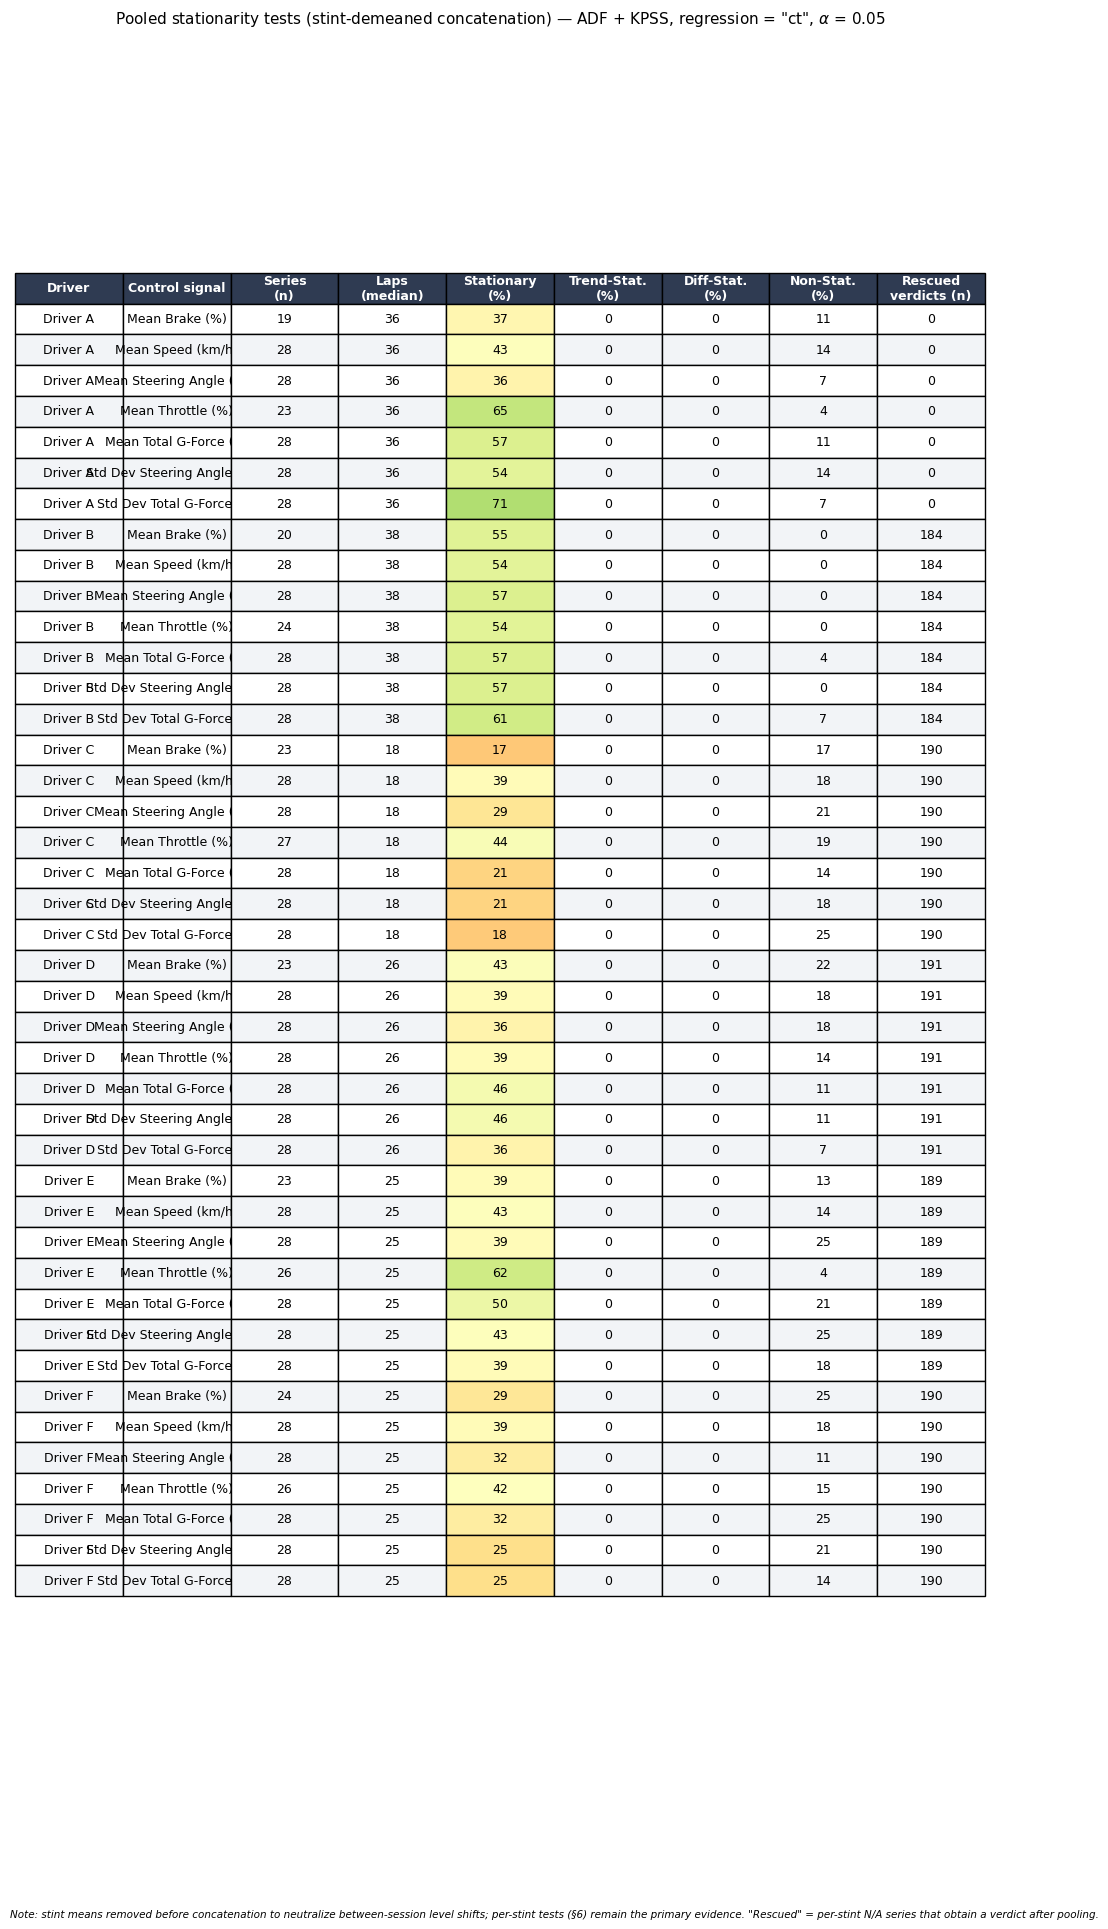

Figura exportada: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\stationarity_analysis\fig_pooled_stationarity_table.pdf


In [71]:
# ══════════════════════════════════════════════════════════════════════════════
# ## 6e. Reviewer Figure — Pooled (Stint-Demeaned) Stationarity Summary (PDF)
# Cole esta célula APÓS a célula do §6d (requer df_results_pooled, df_results,
# rescued, SAVE_DIR já em memória).
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ── 1. Filtra a variante defensável e agrega veredito por Driver × Variável ──
pooled_dm = df_results_pooled[df_results_pooled['Variant'] == 'pooled_demeaned'].copy()

summary = (
    pooled_dm[pooled_dm['Verdict'] != 'N/A']
    .groupby(['Driver', 'Label'])
    .agg(
        N_Series=('Verdict', 'size'),
        N_Laps_Median=('N_Laps', 'median'),
        Pct_Stationary=('Verdict', lambda v: 100 * (v == 'Stationary').mean()),
        Pct_TrendStat=('Verdict', lambda v: 100 * (v == 'Trend-Stationary').mean()),
        Pct_DiffStat=('Verdict', lambda v: 100 * (v == 'Diff-Stationary').mean()),
        Pct_NonStat=('Verdict', lambda v: 100 * (v == 'Non-Stationary').mean()),
    )
    .reset_index()
)

# casos resgatados (N/A por-stint -> veredito com pooling), por driver
rescued_by_driver = (
    rescued.groupby('Driver').size().rename('N_Rescued').reset_index()
)
summary = summary.merge(
    rescued_by_driver, on='Driver', how='left'
).fillna({'N_Rescued': 0})
summary['N_Rescued'] = summary['N_Rescued'].astype(int)

# ── 2. Renderiza como tabela-figura (PDF vetorial) ───────────────────────────
col_labels = ['Driver', 'Control signal', 'Series\n(n)', 'Laps\n(median)',
              'Stationary\n(%)', 'Trend-Stat.\n(%)', 'Diff-Stat.\n(%)',
              'Non-Stat.\n(%)', 'Rescued\nverdicts (n)']

cell_text = []
for _, r in summary.iterrows():
    cell_text.append([
        r['Driver'], r['Label'], f"{r['N_Series']:d}",
        f"{r['N_Laps_Median']:.0f}",
        f"{r['Pct_Stationary']:.0f}", f"{r['Pct_TrendStat']:.0f}",
        f"{r['Pct_DiffStat']:.0f}", f"{r['Pct_NonStat']:.0f}",
        f"{r['N_Rescued']:d}",
    ])

fig, ax = plt.subplots(figsize=(10, 0.42 * len(cell_text) + 1.8))
ax.axis('off')

table = ax.table(cellText=cell_text, colLabels=col_labels,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.55)

# header styling
for j in range(len(col_labels)):
    hdr = table[0, j]
    hdr.set_facecolor('#2f3b52')
    hdr.set_text_props(color='white', fontweight='bold')

# gradient: colore a célula "Stationary (%)" pelo valor (verde forte = mais estacionário)
cmap = plt.cm.RdYlGn
for i, r in summary.reset_index(drop=True).iterrows():
    frac = r['Pct_Stationary'] / 100.0
    table[i + 1, 4].set_facecolor(cmap(0.25 + 0.6 * frac))
    # zebra nas demais colunas
    for j in [0, 1, 2, 3, 5, 6, 7, 8]:
        if i % 2 == 1:
            table[i + 1, j].set_facecolor('#f2f4f7')

ax.set_title(
    'Pooled stationarity tests (stint-demeaned concatenation) — '
    f'ADF + KPSS, regression = "{REGRESSION}", $\\alpha$ = {ALPHA}',
    fontsize=11, pad=14
)
fig.text(0.01, 0.01,
         'Note: stint means removed before concatenation to neutralize between-session '
         'level shifts; per-stint tests (§6) remain the primary evidence. '
         '"Rescued" = per-stint N/A series that obtain a verdict after pooling.',
         fontsize=7.5, style='italic', va='bottom')

fig.tight_layout(rect=[0, 0.05, 1, 1])
out_pdf = SAVE_DIR / 'fig_pooled_stationarity_table.pdf'
fig.savefig(out_pdf, bbox_inches='tight')
plt.show()
print(f'Figura exportada: {out_pdf.resolve()}')

## 7. Verdict Heatmap

In [72]:
'''
VERDICT_COLORS = {
    'Stationary': '#2ecc71', 'Non-Stationary': '#e74c3c',
    'Difference-Stationary': '#f39c12', 'Trend-Stationary': '#3498db', 'N/A': '#bdc3c7',
}
VERDICT_SHORT  = {'Stationary':'S','Non-Stationary':'NS',
                  'Difference-Stationary':'DS','Trend-Stationary':'TS','N/A':'—'}
verdict_order  = list(VERDICT_COLORS.keys())
cmap_v         = ListedColormap(list(VERDICT_COLORS.values()))
bounds_v       = np.arange(-0.5, len(VERDICT_COLORS)+0.5, 1)
norm_v         = BoundaryNorm(bounds_v, cmap_v.N)

for track_id in sorted(df_results['Track'].unique()):
    cfg          = TRACK_CONFIGS[track_id]
    sector_names = cfg['sector_names']
    track_res    = df_results[df_results['Track']==track_id]
    sectors      = sorted(track_res['Sector'].unique())
    sec_labels   = [sector_names.get(s,f'S{s}') for s in sectors]

    for var, label in SECTOR_VARS.items():
        var_res        = track_res[track_res['Variable']==var]
        sessions_local = sorted(var_res[['Driver','Stint']].drop_duplicates()
            .apply(lambda r: f"{r['Driver']} | {r['Stint']}", axis=1).unique())

        matrix_v = pd.DataFrame(index=sessions_local, columns=sectors, dtype=str)
        for _, row in var_res.iterrows():
            matrix_v.at[f"{row['Driver']} | {row['Stint']}", row['Sector']] = row['Verdict']

        matrix_n = matrix_v.applymap(
            lambda v: verdict_order.index(v) if v in verdict_order else len(verdict_order))

        fig, ax = plt.subplots(
            figsize=(max(10,len(sectors)*0.9), max(3,len(sessions_local)*0.7+1.5)))
        ax.imshow(matrix_n.values.astype(float), cmap=cmap_v, norm=norm_v, aspect='auto')
        for i in range(matrix_v.shape[0]):
            for j in range(matrix_v.shape[1]):
                val = matrix_v.iloc[i,j]
                if pd.notna(val) and val != 'nan':
                    ax.text(j, i, VERDICT_SHORT.get(val,val),
                            ha='center', va='center', fontsize=7, fontweight='bold', color='white')
        ax.set_xticks(range(len(sectors)))
        ax.set_xticklabels(sec_labels, rotation=45, ha='right', fontsize=7)
        ax.set_yticks(range(len(sessions_local)))
        ax.set_yticklabels(sessions_local, fontsize=8)
        ax.legend(handles=[Patch(facecolor=c,label=f'{k} ({VERDICT_SHORT[k]})')
                            for k,c in VERDICT_COLORS.items()],
                  loc='upper right', bbox_to_anchor=(1.0,-0.25), ncol=3, fontsize=7)
        ax.set_title(f"Stationarity Verdict — {cfg['track_name']}\n{label}",
                     fontsize=12, fontweight='bold')
        _fname = f'verdict_{var}_{track_id}.{FORMAT}'
        fig.savefig(SAVE_DIR / _fname, dpi=DPI, bbox_inches='tight')
        print(f'  saved: {_fname}')
        plt.tight_layout(); plt.show()
        '''

'\nVERDICT_COLORS = {\n    \'Stationary\': \'#2ecc71\', \'Non-Stationary\': \'#e74c3c\',\n    \'Difference-Stationary\': \'#f39c12\', \'Trend-Stationary\': \'#3498db\', \'N/A\': \'#bdc3c7\',\n}\nVERDICT_SHORT  = {\'Stationary\':\'S\',\'Non-Stationary\':\'NS\',\n                  \'Difference-Stationary\':\'DS\',\'Trend-Stationary\':\'TS\',\'N/A\':\'—\'}\nverdict_order  = list(VERDICT_COLORS.keys())\ncmap_v         = ListedColormap(list(VERDICT_COLORS.values()))\nbounds_v       = np.arange(-0.5, len(VERDICT_COLORS)+0.5, 1)\nnorm_v         = BoundaryNorm(bounds_v, cmap_v.N)\n\nfor track_id in sorted(df_results[\'Track\'].unique()):\n    cfg          = TRACK_CONFIGS[track_id]\n    sector_names = cfg[\'sector_names\']\n    track_res    = df_results[df_results[\'Track\']==track_id]\n    sectors      = sorted(track_res[\'Sector\'].unique())\n    sec_labels   = [sector_names.get(s,f\'S{s}\') for s in sectors]\n\n    for var, label in SECTOR_VARS.items():\n        var_res        = track_res[tr

## 8. ADF p-value Heatmap

In [73]:
'''
for track_id in sorted(df_results['Track'].unique()):
    cfg          = TRACK_CONFIGS[track_id]
    sector_names = cfg['sector_names']
    track_res    = df_results[df_results['Track']==track_id]
    sectors      = sorted(track_res['Sector'].unique())
    sec_labels   = [f"S{s}\n{sector_names.get(s,'')}" for s in sectors]

    for var, label in SECTOR_VARS.items():
        var_res        = track_res[track_res['Variable']==var]
        sessions_local = sorted(var_res[['Driver','Stint']].drop_duplicates()
            .apply(lambda r: f"{r['Driver']} | {r['Stint']}", axis=1).unique())

        matrix_p     = pd.DataFrame(index=sessions_local, columns=sectors, dtype=float)
        matrix_annot = pd.DataFrame(index=sessions_local, columns=sectors, dtype=str)
        for _, row in var_res.iterrows():
            key = f"{row['Driver']} | {row['Stint']}"
            p   = row['ADF_p_value']
            matrix_p.at[key, row['Sector']] = p
            matrix_annot.at[key, row['Sector']] = (
                'N/A' if pd.isna(p) else '<1e-10' if p==0.0
                else f'{p:.2e}' if p<0.001 else f'{p:.3f}')

        fig, ax = plt.subplots(
            figsize=(max(12,len(sectors)*1.1), max(3,len(sessions_local)*1.0+1.5)))
        sns.heatmap(matrix_p.astype(float), ax=ax, cmap='RdYlGn_r', vmin=0, vmax=0.10,
                    annot=matrix_annot, fmt='', linewidths=0.8, linecolor='white',
                    cbar_kws={'label':'ADF p-value','shrink':0.6}, xticklabels=sec_labels)
        for i,sess in enumerate(sessions_local):
            for j,sec in enumerate(sectors):
                p_val = matrix_p.at[sess,sec]
                if pd.notna(p_val) and p_val<0.05:
                    ax.add_patch(plt.Rectangle((j,i),1,1,fill=False,
                                               edgecolor='black',linewidth=2.0,clip_on=False))
        ax.tick_params(axis='x',rotation=45,labelsize=8)
        ax.tick_params(axis='y',rotation=0,labelsize=9)
        ax.set_xlabel('Sector',fontsize=10,labelpad=10)
        ax.set_ylabel('Session',fontsize=10)
        ax.set_title(
            f"ADF p-value per Sector — {cfg['track_name']}\n{label}\n"
            '(green = stationary p<0.05  |  black border = significant)',
            fontsize=12, fontweight='bold', pad=12)
        _fname = f'adf_pvalue_{var}_{track_id}.{FORMAT}'
        fig.savefig(SAVE_DIR / _fname, dpi=DPI, bbox_inches='tight')
        print(f'  saved: {_fname}')
        plt.tight_layout(); plt.show()
        '''

'\nfor track_id in sorted(df_results[\'Track\'].unique()):\n    cfg          = TRACK_CONFIGS[track_id]\n    sector_names = cfg[\'sector_names\']\n    track_res    = df_results[df_results[\'Track\']==track_id]\n    sectors      = sorted(track_res[\'Sector\'].unique())\n    sec_labels   = [f"S{s}\n{sector_names.get(s,\'\')}" for s in sectors]\n\n    for var, label in SECTOR_VARS.items():\n        var_res        = track_res[track_res[\'Variable\']==var]\n        sessions_local = sorted(var_res[[\'Driver\',\'Stint\']].drop_duplicates()\n            .apply(lambda r: f"{r[\'Driver\']} | {r[\'Stint\']}", axis=1).unique())\n\n        matrix_p     = pd.DataFrame(index=sessions_local, columns=sectors, dtype=float)\n        matrix_annot = pd.DataFrame(index=sessions_local, columns=sectors, dtype=str)\n        for _, row in var_res.iterrows():\n            key = f"{row[\'Driver\']} | {row[\'Stint\']}"\n            p   = row[\'ADF_p_value\']\n            matrix_p.at[key, row[\'Sector\']] = p\n     

## 9. Rolling Statistics per Sector

In [74]:
'''
WINDOW = 5
for track_id in sorted(df_sectors['Track'].unique()):
    cfg          = TRACK_CONFIGS[track_id]
    sector_names = cfg['sector_names']
    sectors      = sorted(df_sectors[df_sectors['Track']==track_id]['Sector'].dropna().unique())
    sessions_t   = sorted(df_sectors[df_sectors['Track']==track_id]['Session'].unique())

    for var, label in SECTOR_VARS.items():
        ncols = 4; nrows = (len(sectors)+ncols-1)//ncols
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(5.5*ncols, 3.5*nrows), sharex=False, sharey=False)
        axes = axes.flatten()
        for idx, sec in enumerate(sectors):
            ax     = axes[idx]
            sec_df = df_sectors[(df_sectors['Track']==track_id)&(df_sectors['Sector']==sec)]
            for sess in sessions_t:
                sub = sec_df[sec_df['Session']==sess].sort_values('Lap')
                if sub.empty: continue
                s    = sub[var].reset_index(drop=True)
                laps = sub['Lap'].values
                rm   = s.rolling(WINDOW,center=True).mean()
                rs   = s.rolling(WINDOW,center=True).std()
                c    = cmap_ses[sess]
                ax.plot(laps,s,color=c,alpha=0.25,linewidth=0.8,marker='o',markersize=2)
                ax.plot(laps,rm,color=c,linewidth=1.8,label=sess.split(' | ')[0])
                ax.fill_between(laps,rm-rs,rm+rs,color=c,alpha=0.12)
            ax.set_title(f"S{int(sec):02d} — {sector_names.get(int(sec),f'S{sec}')}",
                         fontsize=8,fontweight='bold')
            ax.set_xlabel('Lap (n)',fontsize=7)
            ax.set_ylabel(label.split(' (')[0],fontsize=7)
            ax.legend(fontsize=6); ax.grid(True,linestyle='--',alpha=0.4)
        for j in range(len(sectors),len(axes)): axes[j].set_visible(False)
        fig.suptitle(f'Rolling Statistics (w={WINDOW}) — {label}\n{cfg["track_name"]}',
                     fontsize=12,fontweight='bold')
        _fname = f'rolling_{var}_{track_id}.{FORMAT}'
        fig.savefig(SAVE_DIR / _fname, dpi=DPI, bbox_inches='tight')
        print(f'  saved: {_fname}')
        plt.tight_layout(); plt.show()
        '''

'\nWINDOW = 5\nfor track_id in sorted(df_sectors[\'Track\'].unique()):\n    cfg          = TRACK_CONFIGS[track_id]\n    sector_names = cfg[\'sector_names\']\n    sectors      = sorted(df_sectors[df_sectors[\'Track\']==track_id][\'Sector\'].dropna().unique())\n    sessions_t   = sorted(df_sectors[df_sectors[\'Track\']==track_id][\'Session\'].unique())\n\n    for var, label in SECTOR_VARS.items():\n        ncols = 4; nrows = (len(sectors)+ncols-1)//ncols\n        fig, axes = plt.subplots(nrows, ncols,\n                                 figsize=(5.5*ncols, 3.5*nrows), sharex=False, sharey=False)\n        axes = axes.flatten()\n        for idx, sec in enumerate(sectors):\n            ax     = axes[idx]\n            sec_df = df_sectors[(df_sectors[\'Track\']==track_id)&(df_sectors[\'Sector\']==sec)]\n            for sess in sessions_t:\n                sub = sec_df[sec_df[\'Session\']==sess].sort_values(\'Lap\')\n                if sub.empty: continue\n                s    = sub[var].reset_i

## 10. Summary — Stationarity Rate per Driver × Track

  saved: stationarity_distribution_alltracks.pdf


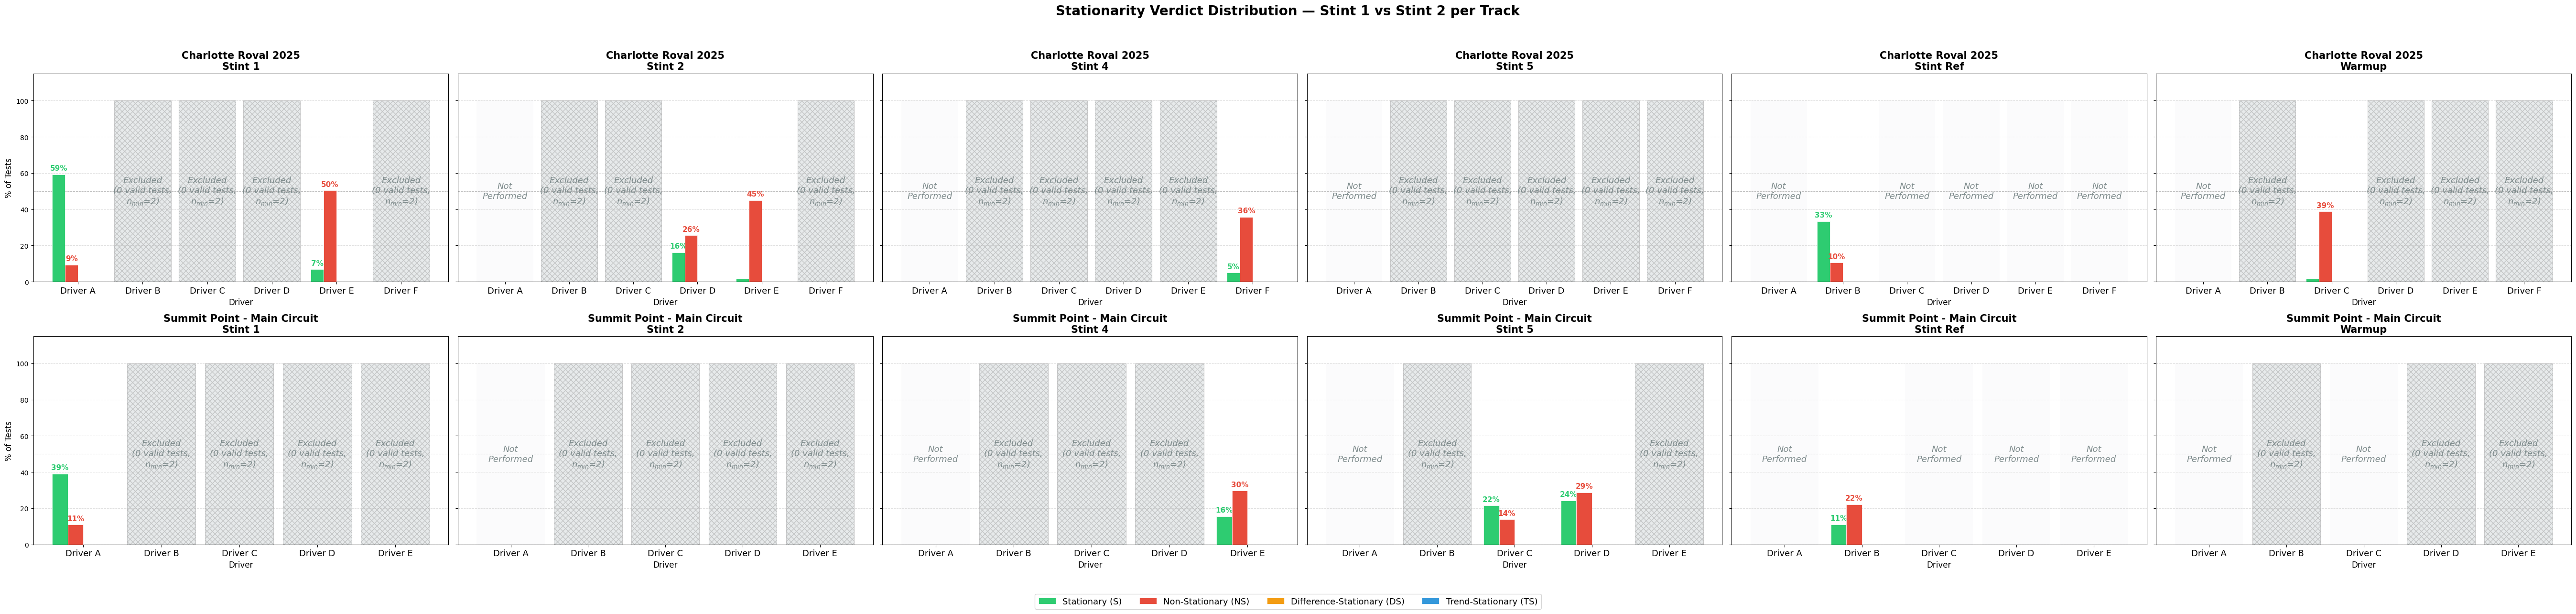

In [75]:
# ══════════════════════════════════════════════════════════════════════════════
# ## 10. Summary — Stationarity Rate per Driver × Track × Stint (2×2 grid)
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

VERDICT_COLS = ['Stationary_%', 'Non-Stationary_%', 'Diff-Stationary_%', 'Trend-Stationary_%']
VERDICT_COLORS_BAR = {
    'Stationary_%':       '#2ecc71',
    'Non-Stationary_%':   '#e74c3c',
    'Diff-Stationary_%':  '#f39c12',
    'Trend-Stationary_%': '#3498db',
}
VERDICT_LABELS_BAR = {
    'Stationary_%':       'Stationary (S)',
    'Non-Stationary_%':   'Non-Stationary (NS)',
    'Diff-Stationary_%':  'Difference-Stationary (DS)',
    'Trend-Stationary_%': 'Trend-Stationary (TS)',
}

# ── build per-stint summary (single source of truth — reused in §11 and §12) ─
summary_stint_rows = []
for (track_id, driver, stint), grp in df_results.groupby(['Track', 'Driver', 'Stint']):
    valid = grp[grp['Verdict'] != 'N/A']
    if valid.empty:
        continue
    v = len(valid)
    summary_stint_rows.append({
        'Track': track_id, 'Driver': driver, 'Stint': stint,
        'N_Tests': v,
        'Stationary_%':       round(100*(valid['Verdict']=='Stationary').sum()/v, 1),
        'Non-Stationary_%':   round(100*(valid['Verdict']=='Non-Stationary').sum()/v, 1),
        'Diff-Stationary_%':  round(100*(valid['Verdict']=='Difference-Stationary').sum()/v, 1),
        'Trend-Stationary_%': round(100*(valid['Verdict']=='Trend-Stationary').sum()/v, 1),
    })
df_summary_stint = pd.DataFrame(summary_stint_rows).sort_values(['Track','Driver','Stint'])

# ── driver-level rollup, collapsed across Track & Stint ─────────────────────
# Cross-driver comparison: who runs a more stationary/non-stationary control
# profile overall, independent of track/stint?
driver_rollup_rows = []
for driver, grp in df_results.groupby('Driver'):
    valid = grp[grp['Verdict'] != 'N/A']
    if valid.empty:
        continue
    v = len(valid)
    driver_rollup_rows.append({
        'Driver': driver,
        'N_Tests': v,
        'Stationary_%':       round(100*(valid['Verdict']=='Stationary').sum()/v, 1),
        'Non-Stationary_%':   round(100*(valid['Verdict']=='Non-Stationary').sum()/v, 1),
        'Diff-Stationary_%':  round(100*(valid['Verdict']=='Difference-Stationary').sum()/v, 1),
        'Trend-Stationary_%': round(100*(valid['Verdict']=='Trend-Stationary').sum()/v, 1),
    })
df_summary_driver = pd.DataFrame(driver_rollup_rows).sort_values('Driver').reset_index(drop=True)

# ── layout: rows = tracks, cols = stints ─────────────────────────────────────
tracks      = sorted(df_summary_stint['Track'].unique())
all_stints  = sorted(df_summary_stint['Stint'].unique())   # ['stint_1', 'stint_2']
n_rows, n_cols = len(tracks), len(all_stints)

# 1. FIGSIZE AMPLIADO para acomodar fontes maiores sem sobreposição
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(9 * n_cols, 6.5 * n_rows),
    sharey=True,
)
if n_rows == 1: axes = axes[np.newaxis, :]
if n_cols == 1: axes = axes[:, np.newaxis]

bar_w   = 0.20 # Barras mais largas
n_verd  = len(VERDICT_COLS)
offsets = np.linspace(-(n_verd-1)/2, (n_verd-1)/2, n_verd) * bar_w

legend_handles = [
    plt.Rectangle((0,0), 1, 1,
                  facecolor=VERDICT_COLORS_BAR[col],
                  edgecolor='white', linewidth=0.5,
                  label=VERDICT_LABELS_BAR[col])
    for col in VERDICT_COLS
]

for r, track_id in enumerate(tracks):
    try:
        track_name = TRACK_CONFIGS[track_id]['track_name']
    except NameError:
        track_name = str(track_id)
        
    drivers    = sorted(df_summary_stint[df_summary_stint['Track']==track_id]['Driver'].unique())
    x          = np.arange(len(drivers))

    for c, stint in enumerate(all_stints):
        ax  = axes[r, c]
        sub = df_summary_stint[
            (df_summary_stint['Track'] == track_id) &
            (df_summary_stint['Stint'] == stint)
        ]

        # ── iterar sobre cada driver para desenhar as barras ou gaps ─
        for i, driver in enumerate(drivers):
            row = sub[sub['Driver'] == driver]

            if row.empty:
                # DISTINÇÃO DINÂMICA: sessão nunca gravada  vs  gravada mas sem
                # nenhum verdict válido (todos os testes deram N/A). Antes este
                # bloco tinha um match hardcoded só para 'Driver C'+'stint_1'+
                # 'summit' -- agora consulta all_dfs diretamente, então
                # acompanha qualquer valor de MIN_VALID_LAPS automaticamente.
                was_loaded = (track_id, driver, stint) in all_dfs

                if was_loaded:
                    msg = f'Excluded\n(0 valid tests,\n$n_{{min}}$={MIN_VALID_LAPS})'
                    hatch_pattern = 'xxx'
                    bg_alpha = 0.35
                    edge_c = 'gray'
                else:
                    msg = 'Not\nPerformed'
                    hatch_pattern = ''
                    bg_alpha = 0.05 # Fundo quase transparente para não poluir
                    edge_c = 'none'

                # Desenha o bloco de fundo para o gap
                ax.bar(x[i], 100, width=bar_w * n_verd * 1.1,
                       color='#bdc3c7', alpha=bg_alpha, hatch=hatch_pattern,
                       edgecolor=edge_c, linewidth=0.8, zorder=1)
                
                # Adiciona o texto centralizado
                ax.text(x[i], 50, msg,
                        ha='center', va='center', fontsize=13,
                        color='#7f8c8d', fontstyle='italic')
                continue

            # Se houver dados, desenha as barras normalmente
            for offset, col in zip(offsets, VERDICT_COLS):
                val   = row[col].values[0]
                color = VERDICT_COLORS_BAR[col]
                bar   = ax.bar(x[i] + offset, val, width=bar_w,
                               color=color, edgecolor='white',
                               linewidth=0.5, zorder=3)
                if val > 3:
                    ax.text(bar[0].get_x() + bar[0].get_width()/2,
                            bar[0].get_height() + 1.5,
                            f'{val:.0f}%',
                            ha='center', va='bottom',
                            fontsize=11, color=color, fontweight='bold')

        # Formatação dos eixos e grid
        ax.set_xticks(x)
        ax.set_xticklabels(drivers, fontsize=13)
        ax.set_ylim(0, 115)
        ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.grid(True, axis='y', linestyle='--', alpha=0.4)
        ax.set_xlabel('Driver', fontsize=12)
        ax.set_ylabel('% of Tests' if c == 0 else '', fontsize=12)
        ax.set_title(
            f'{track_name}\n'
            f'{stint.replace("_", " ").title()}',
            fontsize=15, fontweight='bold'
        )

# ── shared legend at the bottom ───────────────────────────────────────────────
fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
    ncol=4,
    fontsize=13,
    frameon=True,
)
fig.suptitle(
    'Stationarity Verdict Distribution — Stint 1 vs Stint 2 per Track',
    fontsize=20, fontweight='bold',
)

# CRÍTICO: Executar tight_layout ANTES de salvar
plt.tight_layout(rect=[0, 0.06, 1, 0.95])

try:
    _fname = f'stationarity_distribution_alltracks.{FORMAT}'
    fig.savefig(SAVE_DIR / _fname, dpi=DPI, bbox_inches='tight')
    print(f'  saved: {_fname}')
except NameError:
    fig.savefig('stationarity_distribution_alltracks.png', dpi=300, bbox_inches='tight')
    print('  saved: stationarity_distribution_alltracks.png')
    
plt.show()

               Track   Driver     Stint  N_Tests  Stationary_%  Non-Stationary_%  Diff-Stationary_%  Trend-Stationary_%
charlotte_roval_2025 Driver A   stint_1      118          59.3               9.3                0.0                 0.0
charlotte_roval_2025 Driver B stint_ref      114          33.3              10.5                0.0                 0.0
charlotte_roval_2025 Driver C    warmup      121           1.7              38.8                0.0                 0.0
charlotte_roval_2025 Driver D   stint_2      117          16.2              25.6                0.0                 0.0
charlotte_roval_2025 Driver E   stint_1      117           6.8              50.4                0.0                 0.0
charlotte_roval_2025 Driver E   stint_2      120           1.7              45.0                0.0                 0.0
charlotte_roval_2025 Driver F   stint_4      120           5.0              35.8                0.0                 0.0
        summit_point Driver A   stint_1 

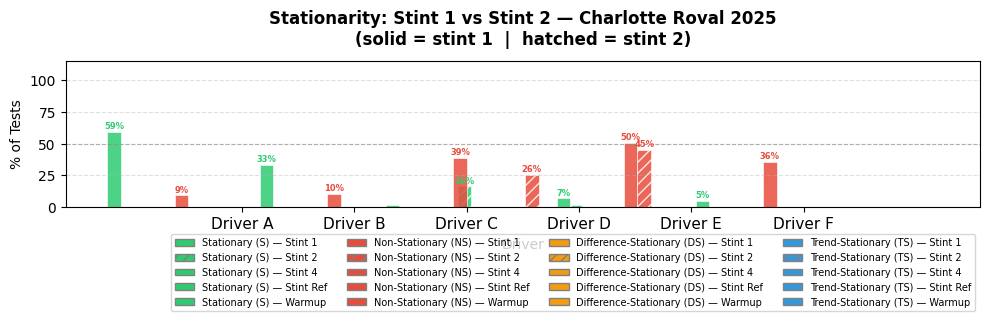

  saved: stationarity_stint_comparison_summit_point.pdf


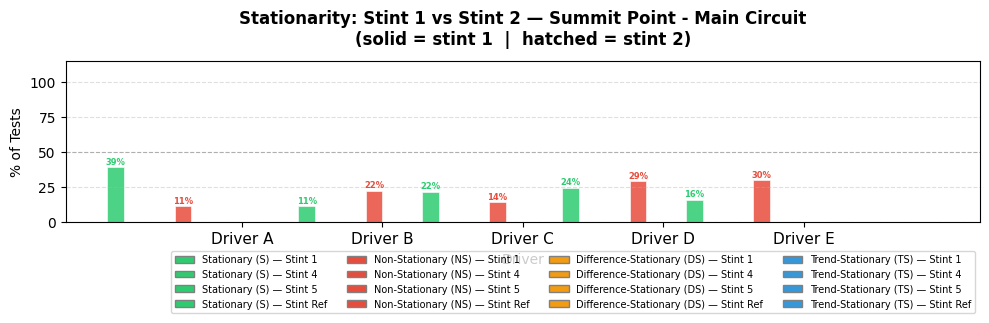

In [76]:
# ══════════════════════════════════════════════════════════════════════════════
# ## 11. Stationarity Comparison — Stint 1 vs Stint 2 per Driver × Track
# ══════════════════════════════════════════════════════════════════════════════

import itertools

# ── 11a. Reuse df_summary_stint built in §10 (single source of truth) ───────
print(df_summary_stint.to_string(index=False))

# ── 11b. Delta table: Stationary_% change from stint_1 → stint_2 ─────────────
delta_rows = []
for (track_id, driver), grp in df_summary_stint.groupby(['Track', 'Driver']):
    stints = grp.set_index('Stint')
    if 'stint_1' not in stints.index or 'stint_2' not in stints.index:
        continue
    for col in ['Stationary_%', 'Non-Stationary_%', 'Diff-Stationary_%', 'Trend-Stationary_%']:
        delta = stints.at['stint_2', col] - stints.at['stint_1', col]
        delta_rows.append({'Track': track_id, 'Driver': driver,
                           'Metric': col, 'Stint1': stints.at['stint_1', col],
                           'Stint2': stints.at['stint_2', col], 'Delta': round(delta, 1)})

df_delta = pd.DataFrame(delta_rows)

# ── 11c. Grouped bar chart: stint_1 vs stint_2, one panel per track ──────────
VERDICT_COLS   = ['Stationary_%', 'Non-Stationary_%', 'Diff-Stationary_%', 'Trend-Stationary_%']
VERDICT_COLORS_BAR = {
    'Stationary_%':       '#2ecc71',
    'Non-Stationary_%':   '#e74c3c',
    'Diff-Stationary_%':  '#f39c12',
    'Trend-Stationary_%': '#3498db',
}
VERDICT_LABELS_BAR = {
    'Stationary_%':       'Stationary (S)',
    'Non-Stationary_%':   'Non-Stationary (NS)',
    'Diff-Stationary_%':  'Difference-Stationary (DS)',
    'Trend-Stationary_%': 'Trend-Stationary (TS)',
}
STINT_HATCH = {'stint_1': '', 'stint_2': '///'}   # solid = stint 1, hatched = stint 2

tracks = sorted(df_summary_stint['Track'].unique())

for track_id in tracks:
    sub = df_summary_stint[df_summary_stint['Track'] == track_id]
    drivers = sorted(sub['Driver'].unique())
    stints  = sorted(sub['Stint'].unique())          # e.g. ['stint_1', 'stint_2']
    n_groups = len(drivers)
    n_bars   = len(VERDICT_COLS) * len(stints)       # bars per driver cluster
    bar_w    = 0.12
    offsets  = np.linspace(-(n_bars - 1) / 2, (n_bars - 1) / 2, n_bars) * bar_w

    fig, ax = plt.subplots(figsize=(max(10, n_groups * 1.5), 3.5))
    x = np.arange(n_groups)

    bar_idx = 0
    legend_handles = []
    for col, color in VERDICT_COLORS_BAR.items():
        for stint in stints:
            values = [
                sub[(sub['Driver'] == d) & (sub['Stint'] == stint)][col].values[0]
                if not sub[(sub['Driver'] == d) & (sub['Stint'] == stint)].empty else 0.0
                for d in drivers
            ]
            hatch = STINT_HATCH.get(stint, '')
            bars  = ax.bar(x + offsets[bar_idx], values, width=bar_w,
                           color=color, hatch=hatch, edgecolor='white',
                           linewidth=0.5, alpha=0.85)
            for bar, val in zip(bars, values):
                if val > 2:
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() + 0.8,
                            f'{val:.0f}%', ha='center', va='bottom',
                            fontsize=6, color=color, fontweight='bold')
            # legend entry only once per (verdict × stint)
            legend_handles.append(
                Patch(facecolor=color, hatch=hatch, edgecolor='gray',
                      label=f"{VERDICT_LABELS_BAR[col]} — {stint.replace('_', ' ').title()}")
            )
            bar_idx += 1

    ax.set_xticks(x)
    ax.set_xticklabels(drivers, fontsize=11)
    ax.set_ylabel('% of Tests', fontsize=10)
    ax.set_xlabel('Driver', fontsize=10)
    ax.set_ylim(0, 115)
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.legend(handles=legend_handles, fontsize=7, loc='upper right',
              bbox_to_anchor=(1.0, -0.15), ncol=4)
    ax.set_title(
        f'Stationarity: Stint 1 vs Stint 2 — {TRACK_CONFIGS[track_id]["track_name"]}\n'
        '(solid = stint 1  |  hatched = stint 2)',
        fontsize=12, fontweight='bold', pad=12)

    _fname = f'stationarity_stint_comparison_{track_id}.{FORMAT}'
    fig.savefig(SAVE_DIR / _fname, dpi=DPI, bbox_inches='tight')
    print(f'  saved: {_fname}')
    plt.tight_layout()
    plt.show()


## 12. Final Summary Table — Cross-Driver Stationarity Comparison

This is the **final, consolidated output** of the notebook: per-stint and per-driver
stationarity summaries, a cross-driver contingency comparison, and CSV export for
direct use in the manuscript (Methods / Supplementary Material).

In [77]:
# ══════════════════════════════════════════════════════════════════════════════
# ## 12. Final Summary Table — Cross-Driver Stationarity Comparison
# ══════════════════════════════════════════════════════════════════════════════
from IPython.display import display

print('=== Summary by Track x Driver x Stint ===')
display(df_summary_stint)

print('\n=== Summary by Driver (collapsed across Track & Stint) ===')
display(df_summary_driver)

# ── cross-driver statistical comparison ──────────────────────────────────────
# H0: the Verdict distribution (Stationary / Non-Stationary / Diff-Stationary /
#     Trend-Stationary) is independent of Driver
# H1: the Verdict distribution differs by Driver
# Uses raw per-test counts (df_results), not the %-tables above, since a
# chi-square test needs frequencies. N here is the number of
# (sector x variable x lap-series) tests per driver -- NOT N=3 pilots.
# This is a within-pilot control-input comparison, not the between-subject
# N=3 comparison flagged by reviewers elsewhere in the manuscript.
from scipy.stats import chi2_contingency

valid_results = df_results[df_results['Verdict'] != 'N/A']
contingency   = pd.crosstab(valid_results['Driver'], valid_results['Verdict'])
print('\n=== Contingency table: Driver x Verdict (test counts) ===')
display(contingency)

chi2, p_chi, dof, expected = chi2_contingency(contingency)
print(f'\nChi-square test of independence (Driver x Verdict)')
print(f'  chi2 = {chi2:.3f}, dof = {dof}, p = {p_chi:.4g}')
if p_chi < ALPHA:
    print(f'  -> Reject H0 (p < {ALPHA}): stationarity profile differs significantly by driver.')
else:
    print(f'  -> Fail to reject H0 (p >= {ALPHA}): no significant evidence that the '
          f'stationarity profile differs by driver.')
print('  Caveat: sector-level tests within a driver/session are not fully independent '
      '(shared session, autocorrelated control inputs) -- treat as descriptive, '
      'exploratory evidence rather than a strict i.i.d. hypothesis test.')

# ── export tables for manuscript use ─────────────────────────────────────────
df_summary_stint.to_csv(SAVE_DIR / 'summary_stationarity_by_stint.csv', index=False)
df_summary_driver.to_csv(SAVE_DIR / 'summary_stationarity_by_driver.csv', index=False)
contingency.to_csv(SAVE_DIR / 'contingency_driver_verdict.csv')

print(f'\nExported summary tables to: {SAVE_DIR.resolve()}')
print('  - summary_stationarity_by_stint.csv')
print('  - summary_stationarity_by_driver.csv')
print('  - contingency_driver_verdict.csv')

=== Summary by Track x Driver x Stint ===


,Track,Driver,Stint,N_Tests,Stationary_%,Non-Stationary_%,Diff-Stationary_%,Trend-Stationary_%
0,charlotte_roval_2025,Driver A,stint_1,118,59.3,9.3,0.0,0.0
1,charlotte_roval_2025,Driver B,stint_ref,114,33.3,10.5,0.0,0.0
2,charlotte_roval_2025,Driver C,warmup,121,1.7,38.8,0.0,0.0
3,charlotte_roval_2025,Driver D,stint_2,117,16.2,25.6,0.0,0.0
4,charlotte_roval_2025,Driver E,stint_1,117,6.8,50.4,0.0,0.0
5,charlotte_roval_2025,Driver E,stint_2,120,1.7,45.0,0.0,0.0
6,charlotte_roval_2025,Driver F,stint_4,120,5.0,35.8,0.0,0.0
7,summit_point,Driver A,stint_1,64,39.1,10.9,0.0,0.0
8,summit_point,Driver B,stint_ref,63,11.1,22.2,0.0,0.0
9,summit_point,Driver C,stint_5,65,21.5,13.8,0.0,0.0



=== Summary by Driver (collapsed across Track & Stint) ===


,Driver,N_Tests,Stationary_%,Non-Stationary_%,Diff-Stationary_%,Trend-Stationary_%
0,Driver A,182,52.2,9.9,0.0,0.0
1,Driver B,177,25.4,14.7,0.0,0.0
2,Driver C,186,8.6,30.1,0.0,0.0
3,Driver D,183,19.1,26.8,0.0,0.0
4,Driver E,301,6.6,43.9,0.0,0.0
5,Driver F,120,5.0,35.8,0.0,0.0



=== Contingency table: Driver x Verdict (test counts) ===


Verdict,Conflicting,Inconclusive,Non-Stationary,Stationary
Driver,,,,
Driver A,13,56,18,95
Driver B,19,87,26,45
Driver C,42,72,56,16
Driver D,36,63,49,35
Driver E,65,84,132,20
Driver F,39,32,43,6



Chi-square test of independence (Driver x Verdict)
  chi2 = 272.633, dof = 15, p = 2.642e-49
  -> Reject H0 (p < 0.05): stationarity profile differs significantly by driver.
  Caveat: sector-level tests within a driver/session are not fully independent (shared session, autocorrelated control inputs) -- treat as descriptive, exploratory evidence rather than a strict i.i.d. hypothesis test.

Exported summary tables to: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\stationarity_analysis
  - summary_stationarity_by_stint.csv
  - summary_stationarity_by_driver.csv
  - contingency_driver_verdict.csv


chi2(15) = 272.6, p = 2.64e-49
min expected count = 22.3 (rule of thumb: >= 5)
saved: verdict_composition_gestalt.pdf


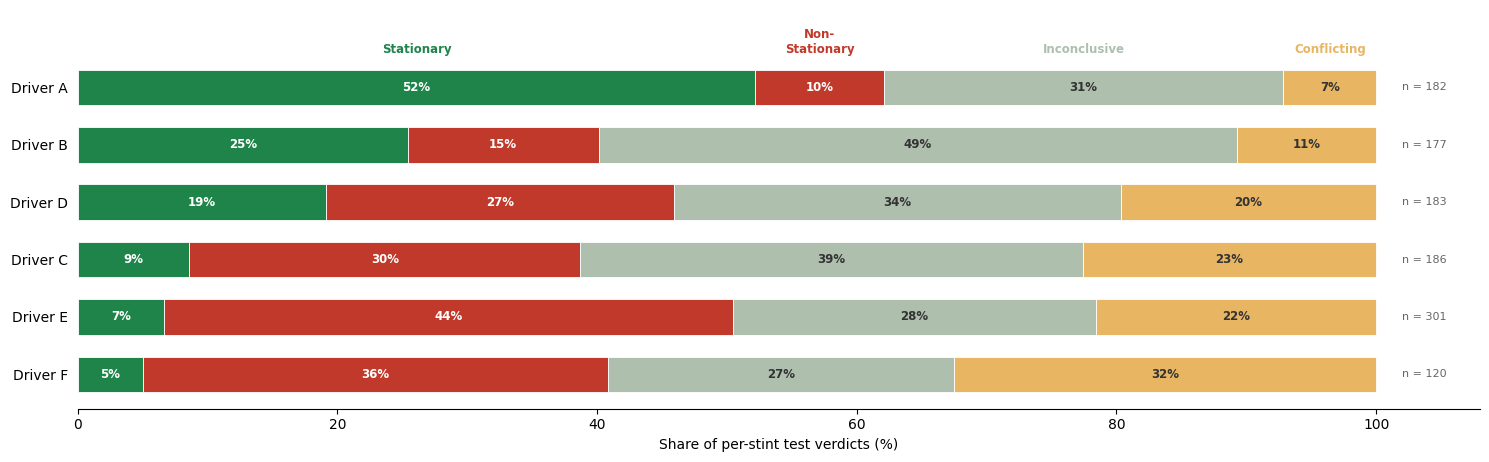

In [79]:
# ══════════════════════════════════════════════════════════════════════════════
# ## 13. Publication Figure — Verdict Composition per Driver (Gestalt-revised)
# ##     Single panel · empty categories dropped · drivers ordered by proficiency
# ##     Significant cells (|Pearson residual| > 2) outlined in black
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# ── 13a. Contingency table (reuses df_results from §6) ───────────────────────
valid_results = df_results[df_results['Verdict'] != 'N/A']
cont_full = pd.crosstab(valid_results['Driver'], valid_results['Verdict'])

# Prägnanz: drop verdict categories with zero counts everywhere (e.g. DS).
# A zero column would also break expected-count computation (E = 0).
empty_cols = [c for c in cont_full.columns if cont_full[c].sum() == 0]
if empty_cols:
    print(f'Dropped empty verdict categories: {empty_cols} '
          f'(declare this in the manuscript text/caption)')
cont = cont_full.drop(columns=empty_cols)

CAT_ORDER = [c for c in ['Stationary', 'Non-Stationary',
                         'Inconclusive', 'Conflicting']
             if c in cont.columns]
cont = cont[CAT_ORDER]

# ── 13b. Chi-square + Pearson residuals ──────────────────────────────────────
chi2, p_chi, dof, expected = chi2_contingency(cont)
resid = (cont - expected) / np.sqrt(expected)          # Pearson residuals

print(f'chi2({dof}) = {chi2:.1f}, p = {p_chi:.3g}')
print(f'min expected count = {expected.min():.1f} (rule of thumb: >= 5)')

# ── 13c. Figure — 100% stacked bars, ordered by Stationary share ─────────────
shares = cont.div(cont.sum(axis=1), axis=0) * 100
driver_order = shares['Stationary'].sort_values(ascending=False).index.tolist()

# Figure-ground: saturated poles (S green, NS red), desaturated middle (TS)
CAT_COLORS = {'Stationary':     '#1e8449',
              'Non-Stationary': '#c0392b',
              'Inconclusive':   '#aebfae',
              'Conflicting':    '#e8b563'}
CAT_TXT    = {'Stationary': 'white', 'Non-Stationary': 'white',
              'Inconclusive': '#333333', 'Conflicting': '#333333'}

fig, ax = plt.subplots(figsize=(15, 0.62 * len(driver_order) + 1))

y = np.arange(len(driver_order))[::-1]          # top = most stationary
seg_geom = {}                                    # (driver, cat) -> (x0, width)

for yi, drv in zip(y, driver_order):
    x0 = 0.0
    for cat in CAT_ORDER:
        w = shares.at[drv, cat]
        ax.barh(yi, w, left=x0, height=0.62,
                color=CAT_COLORS[cat],
                edgecolor='white', linewidth=0.6, zorder=2)
        if w >= 3:
            ax.text(x0 + w / 2, yi, f'{w:.0f}%', ha='center', va='center',
                    fontsize=8.5, fontweight='bold', color=CAT_TXT[cat])
        seg_geom[(drv, cat)] = (x0, w)
        x0 += w
    ax.text(102, yi, f'n = {cont.loc[drv].sum()}', va='center',
            fontsize=8, color='#666666')

# Proximity: direct labels above the top bar replace the floating legend
top_drv = driver_order[0]
for cat in CAT_ORDER:
    x0, w = seg_geom[(top_drv, cat)]
    ax.text(x0 + w / 2, y[0] + 0.55, cat.replace('-', '-\n'),
            ha='center', va='bottom', fontsize=8.5,
            color=CAT_COLORS[cat] if cat != 'Trend-Stationary' else '#6b7d6b',
            fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(driver_order, fontsize=10)
ax.set_xlim(0, 108)
ax.set_ylim(-0.6, len(driver_order) + 0.35)
ax.set_xlabel('Share of per-stint test verdicts (%)', fontsize=10)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
# No chi2 in the title — statistics belong in the caption/text (MDPI style)
#ax.set_title('Stationarity verdict composition per driver\n''(black outline: cell drives the association, 'r'$|r_{\mathrm{Pearson}}| > 2$)',fontsize=10.5, pad=22)

plt.tight_layout()
_fname = f'verdict_composition_gestalt.{FORMAT}'
fig.savefig(SAVE_DIR / _fname, dpi=DPI, bbox_inches='tight')
print(f'saved: {_fname}')
plt.show()


